In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid19-coronavirus-pandemic/COVID-19 Coronavirus.csv


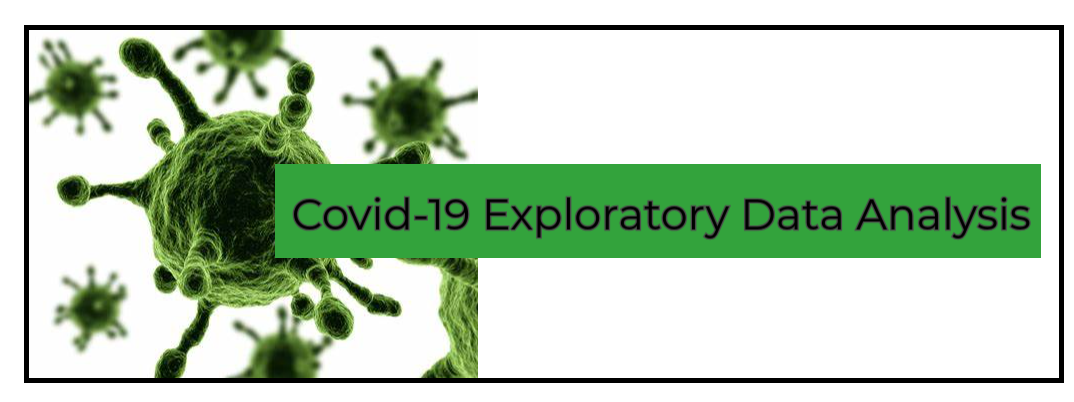

<div style="background-color:green; color: white; padding: 10px;">
    <h1 style="text-align: center; font-size: 30px;"> Dependencies </h1>
</div>

In [2]:
import warnings

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go 


In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)

## Data set 

In [4]:
data = pd.read_csv('/kaggle/input/covid19-coronavirus-pandemic/COVID-19 Coronavirus.csv')



<div style="background-color:green; color: white; padding: 10px;">
    <h1 style="text-align: center; font-size: 30px;"> Understanding the data </h1>
</div>

In [5]:
# Display first 5 rows 
data.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438


In [6]:
# Data dimensions
data.shape

(225, 10)

In [7]:
# Information about the data 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  225 non-null    object 
 1   Other names              224 non-null    object 
 2   ISO 3166-1 alpha-3 CODE  225 non-null    object 
 3   Population               225 non-null    int64  
 4   Continent                225 non-null    object 
 5   Total Cases              225 non-null    int64  
 6   Total Deaths             225 non-null    int64  
 7   Tot Cases//1M pop        225 non-null    int64  
 8   Tot Deaths/1M pop        225 non-null    int64  
 9   Death percentage         225 non-null    float64
dtypes: float64(1), int64(5), object(4)
memory usage: 17.7+ KB


In [8]:
# Get a statistical summary of the numerical variables in the data
data.describe()

,Population,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
count,2.250000e+02,2.250000e+02,2.250000e+02,225.000000,225.000000,225.000000
mean,3.507321e+07,2.184781e+06,2.744813e+04,136900.373333,1096.715556,1.444125
std,1.392418e+08,7.275938e+06,9.689177e+04,145060.340289,1195.715543,1.741728
min,8.050000e+02,1.000000e+00,0.000000e+00,9.000000,0.000000,0.000000
25%,5.665570e+05,2.407100e+04,1.890000e+02,11384.000000,123.000000,0.511291
50%,5.827911e+06,1.639360e+05,1.965000e+03,88987.000000,708.000000,1.036905
75%,2.190585e+07,1.092547e+06,1.366000e+04,223335.000000,1795.000000,1.977017
max,1.439324e+09,8.183905e+07,1.008222e+06,696044.000000,6286.000000,18.151787


In [9]:
# Check if there is any duplicated records 
data.duplicated().any()

False

In [10]:
# Check if there are missing values
data.isna().sum()

Country                    0
Other names                1
ISO 3166-1 alpha-3 CODE    0
Population                 0
Continent                  0
Total Cases                0
Total Deaths               0
Tot Cases//1M pop          0
Tot Deaths/1M pop          0
Death percentage           0
dtype: int64

In [11]:
data[data['Other names'].isnull()]

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
135,Montenegro,NaN,MNE,628205,Europe,233326,2705,371417,4306,1.159322




<div style="background-color:green; color: white; padding: 10px;">
    <h1 style="text-align: center; font-size: 30px;"> Data Cleaning </h1>
</div>

<font size=4>For consistency, ease of access and better readability we will rename the column names.</font>

In [12]:
df = data.copy()

In [13]:
# Columns before change
df.columns

Index(['Country', 'Other names', 'ISO 3166-1 alpha-3 CODE', 'Population',
       'Continent', 'Total Cases', 'Total Deaths', 'Tot Cases//1M pop',
       'Tot Deaths/1M pop', 'Death percentage'],
      dtype='object')

In [14]:
# Rename column names 
df.rename(columns = {'Tot\xa0Cases//1M pop' : 'Total Cases per 1M pop',
                    'Tot\xa0Deaths/1M pop': 'Total Deaths per 1M pop'}, inplace=True)

In [15]:
# Convert columns names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns = df.columns.str.replace('/', '_')


In [16]:
# Column names after change
df.columns

Index(['country', 'other_names', 'iso_3166-1_alpha-3_code', 'population',
       'continent', 'total_cases', 'total_deaths', 'total_cases_per_1m_pop',
       'total_deaths_per_1m_pop', 'death_percentage'],
      dtype='object')



<div style="background-color:green; color: white; padding: 10px;">
    <h1 style="text-align: center; font-size: 30px;"> Data Visualization</h1>
</div>

## Total Cases Per Continent

In [17]:
# Total Cases per continent
df_cases_per_continent = df.groupby(['continent'])['total_cases'].sum().reset_index(name='counts')
df_cases_per_continent 

,continent,counts
0,Africa,11764207
1,Asia,140957179
2,Europe,180332483
3,Latin America and the Caribbean,67509231
4,Northern America,85364770
5,Oceania,5647957


In [18]:
fig = px.pie(df_cases_per_continent, values='counts', names='continent', hole = 0.5 )

for data in fig.data:
    data.hovertemplate = '%{label}<br>Total Cases:%{value}'

fig.update_layout(
    autosize = False,
    title = dict(
        text ='Distribution of Covid-19 Across Continents',
        x = 0.2,
        y = 0.93)
)

fig.show()

<font size= 5, color=darkgreen><b><u>Observations:</u></b></font>

<font size= 4> These percentages are based on the total number of reported cases.</font> 

* <font size= 4> Europe has the highest percentage of reported cases.</font> 
* <font size= 4> Europe and Asia have the majority of reported cases.</font> 
* <font size= 4> Africa has of the lowest percentage of reported cases.</font> 


## Top 20 Countries in Europe With the Most Recorded Deaths

In [19]:
# Filter for all records from Europe
df_europe = df[df['continent'] == 'Europe']
df_deaths_per_country = df_europe.groupby(['country'])['total_deaths'].sum().reset_index(name='counts')
df_deaths_per_country.sort_values(by = 'counts', ascending=False, inplace=True)
df_top_20_most_deaths = df_deaths_per_country.reset_index().head(20)

In [20]:
fig = px.bar(df_top_20_most_deaths, x = 'country', y = 'counts', color = 'country')
fig.update_layout(
    title = dict(
        text = 'Top 20 European Countries with Highest Death Toll',
        x = 0.2,
        y = 0.93
    ),
    legend = dict(
        title = 'Country'
    ),
    xaxis_title = ' ',
    yaxis_title = 'Total Deaths'
)
fig.update_traces(
    hovertemplate = '<b>%{x}</b><br>Total Deaths: %{y}'
)   
fig.update_xaxes(tickangle=90)
fig.show()

<font size= 5, color=darkgreen><b><u>Observations:</u></b></font>

<font size= 4>We previously saw that Europe had the highest percentage of Total Covid_19 Cases.</font>

* <font size= 4>Russia has a significantly higher death toll compared to the other countries.</font>
* <font size= 4>UK has the second highest death toll, more than Italy where the disease was first recorded.</font>
* <font size= 4>The rest of the European countries had death tolls less than Serbia's 15 825.</font>

## Impact of Covid-19 relative to the size of the Population

In [21]:
df.columns

Index(['country', 'other_names', 'iso_3166-1_alpha-3_code', 'population',
       'continent', 'total_cases', 'total_deaths', 'total_cases_per_1m_pop',
       'total_deaths_per_1m_pop', 'death_percentage'],
      dtype='object')

In [22]:
#df_europe = df[df['continent'] == 'Europe']
df_deaths_per_country_std = df_europe.groupby(['country'])['total_deaths_per_1m_pop'].sum().reset_index(name='counts')
df_deaths_per_country_std.sort_values(by = 'counts', ascending=False, inplace=True)
df_top_20_most_deaths_std = df_deaths_per_country_std.reset_index().head(20)

In [23]:
fig = px.bar(df_top_20_most_deaths_std,x = 'counts',
             y = 'country',orientation = 'h', color = 'country')
fig.update_layout(
    title = dict(
        text = 'COVID-19 Impact: Top 20 European Countries by Death Toll per Million Population',
        x = 0.1,
        y = 0.95
    ),
    legend = dict(
        title = 'Country'
    ),
    xaxis_title = ' ',
    yaxis_title = ' '
)
fig.update_traces(
    hovertemplate = '<b>%{y}</b><br>Deaths/1M Pop : %{x}'
)   
fig.update_xaxes(visible=False)
fig.show()

<font size= 5, color=darkgreen><b><u>Observations:</u></b></font>

<font size= 4>We previously saw that Russia had the highest death toll in Europe. However Russia also has the highest population. When we standardize the number of deaths across different population sizes :</font>

* <font size= 4>Russia has the lowest death toll per 1 million population out of the Top 20 countries.</font>
* <font size= 4>Bulgaria has the highest death toll per 1 million population.</font>
* <font size= 4>The majority of the countries with the highest death toll per million population are from Eastern Europe.</font>


In [24]:
# Create a list of unique continents
continents = df['continent'].unique()

# Initialize an empty list to store all the scatter plots and line plots
data = []

# Create scatter and line plots for each continent
for continent in continents:
    # Filter the dataframe for the current continent
    df_continent = df[df['continent'] == continent]
    
    # Create scatter plot for the current continent
    scatter = go.Scatter(x=df_continent['country'], 
                         y=df_continent['death_percentage'], 
                         mode='markers', 
                         marker=dict(size=10), 
                         name=continent)
    data.append(scatter)
    
    # Create line plots for each country in the current continent
    for i, country in enumerate(df_continent['country']):
        line = go.Scatter(x=[country, country], 
                          y=[0, df_continent['death_percentage'].iloc[i]], 
                          mode='lines', 
                          marker=dict(color='gray'),
                          showlegend=False)
        data.append(line)

# Create the figure
fig = go.Figure(data=data)

# Update layout to move legend below plot and increase figure size
fig.update_layout(
    title=dict(
        text='COVID-19 Death Percentage by Country Across Continents',
        x = 0.5,
        y = 0.93
    ),
    legend=dict(x=0, y=-0.5, orientation='h'),
    autosize=False,
    width=800,
    height=600
)
# Show the figure
fig.show()


<font size= 5, color=darkgreen><b><u>Observations:</u></b></font>


<font size= 4>Death percentage = Total deaths / Total cases</font>

* <font size= 4>Asia: Yemen has the highest death percentage.</font>
* <font size= 4>Africa: Western Sahara has the highest death percentage.</font>
* <font size= 4>Oceania: Wallis and Futana has the highest death percentage.</font>
* <font size= 4>Europe: Bosnia and Herzegovina has the highest death percentage.</font>
* <font size= 4>Latin America and the Caribbean :  Peru has the highest death percentage.</font>
* <font size= 4>Northern America : USA has the highest death percentage.</font>